## Ejercicio de Feedback: Clustering

Autor: María León Pérez

# Introducción y planteamiento del problema

"**Ayuda Internacional**" es una ONG humanitaria internacional comprometida con la lucha contra la pobreza y con proporcionar a las personas de países subdesarrollados servicios básicos y ayuda en tiempos de desastres y calamidades naturales. Esta ONG ha logrado recaudar aproximadamente 10 millones de dólares. Este dinero debe ahora asignarse de manera estratégica y eficaz. Por lo tanto, para decidir la selección de los países que más necesitan ayuda, se deben tomar decisiones basadas en datos.

En consecuencia, resulta necesario **categorizar los países utilizando factores socioeconómicos y de salud** que determinen el desarrollo general de cada país. Basándose en estos grupos de países, definidos por sus condiciones, se distribuirán los fondos para brindar asistencia durante desastres y calamidades naturales. Este es un caso claro de clustering, donde se requiere crear grupos de países basados en las diferentes características presentes.

**Objetivo**:


*   Agrupar países en función de características numéricas socioeconómicas.
*   Determinar qué grupos de países requieren ayuda y en qué grado



## Nuestro conjunto de datos




* **country**: Nombre del país.
* **child_mort**: Muertes de niños menores de 5 años por cada 1000 nacidos vivos.
* **exports**: Exportaciones de bienes y servicios per cápita, expresadas como porcentaje del PIB per cápita.
* **health**: Gasto total en salud per cápita, expresado como porcentaje del PIB per cápita.
* **imports**: Importaciones de bienes y servicios per cápita, expresadas como porcentaje del PIB per cápita.
* **Income**: Ingreso neto por persona.
* **Inflation**: Tasa de crecimiento anual del PIB total.
* **life_expec**: Número promedio de años que un recién nacido viviría si se mantienen los patrones actuales de mortalidad.
* **total_fer**: Número de hijos que nacerían por mujer si las tasas actuales de fertilidad por edad permanecen constantes.
* **gdpp**: PIB per cápita, calculado como el PIB total dividido entre la población total.




## 1 Importación de librerías

In [59]:
#Es posible que necesitéis estas librerías (y muchas más)
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px
!pip install -U kaleido
import kaleido
from google.colab import files #para cargar archivos desde el ordenador
import pandas as pd #para trabajar con datasets
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

## 2 Análisis Exploratorio de los datos

**Ejercicio 1** - Llevar a cabo un procedimiento de EDA para obtener información acerca de los datos:

*  Declara el tamaño del dataset y muestra algunos registros por pantalla. Muestra los estadísticos (media, desviación típica, min, max...) relevantes de cada una de las variables. Observando el tipo de características, ¿podemos usarlas todas en un algoritmo de agrupación?

*  Analiza la distribución de cada una de las variables mediante gráficas de densidad y boxplots (se valora utilizar el mínimo código posible para mostrar todas las gráficas). ¿Están bien distribuidas las variables? ¿Qué podemos comentar de este análisis?



Las ONG que operan a nivel internacional necesitan priorizar recursos limitados hacia los países con mayores necesidades. El objetivo de este trabajo es identificar grupos de países en función de indicadores socioeconómicos y de salud, con el fin de proponer una estrategia de priorización basada en datos.

In [60]:
#CARGA DE ARCHIVOS (si se sube desde el ordenador)
#descomentar la opción usada
uploaded = files.upload()
#nombre_archivo = list(uploaded.keys())[0]
nombre_archivo = "Country-data.csv"

#cargar el dataset
df=pd.read_csv(nombre_archivo)

Saving Country-data.csv to Country-data (2).csv


In [61]:
#TAMAÑO DEL DATASET
#Sacamos 15 registros por pantalla para observar nuestros datos
df.head(15)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840


In [62]:
#mostrar estadísticos más importantes
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [63]:
#tipo de dato de cada variable del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


A excepción del nombre del país, todas las demás variables son numéricas. K-means solo funciona con variables cuantitativas, por lo que no hace falta eliminar ninguna columna (el nombre del país podría sernos útil).

Respondiendo a la pregunta de si podemos usar todas las variables en un algoritmo de agrupación, no podríamos usar bajo ningún concepto la variable country debido a su tipología (object), k-means no puede procesarlo. Para visualizar los clusters resultantes, podríamos aplicar PCA y reducir a 2-3 dimensiones, aunque K-means puede trabajar con todas las variables originales.

Existirá al menos un clúster de países con alta mortalidad infantil, baja esperanza de vida y bajos ingresos, que debería ser prioritario. Variables como income, gdpp y child_mort estarán fuertemente correlacionadas y condicionarán la formación de los clústers.

A continuación vamos a realizar una visualización del gráfico de densidad de cada una de las variables para ver cómo se distribuyen.

/tmp/ipython-input-3633973471.py:1: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




<Axes: xlabel='child_mort', ylabel='Density'>

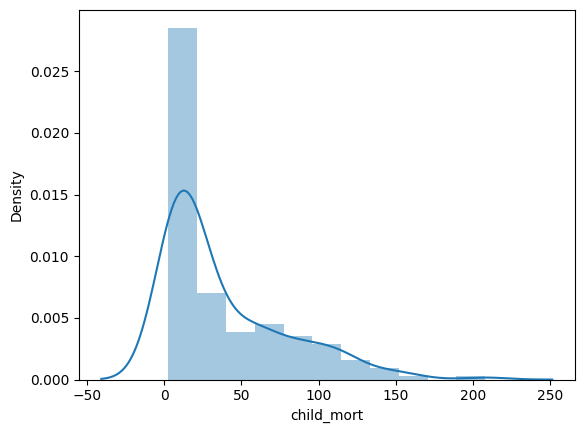

In [64]:
sns.distplot(df["child_mort"])

/tmp/ipython-input-615979505.py:1: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




<Axes: xlabel='exports', ylabel='Density'>

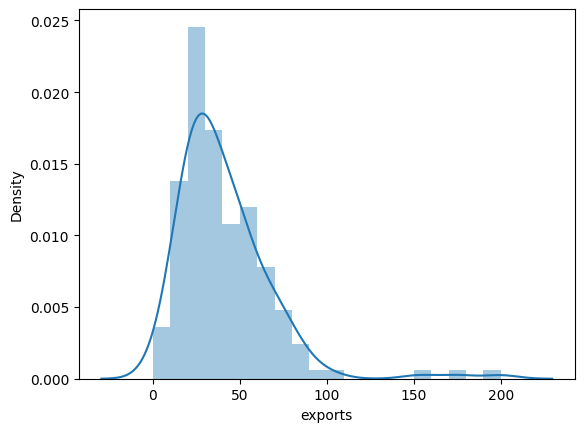

In [65]:
sns.distplot(df["exports"])

/tmp/ipython-input-968483258.py:1: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




<Axes: xlabel='health', ylabel='Density'>

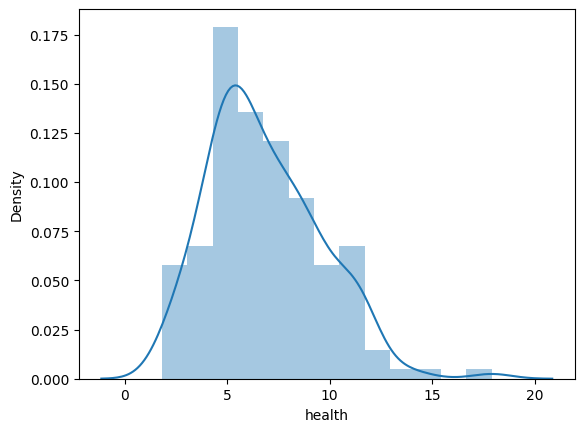

In [66]:
sns.distplot(df["health"])

/tmp/ipython-input-1225239699.py:1: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




<Axes: xlabel='imports', ylabel='Density'>

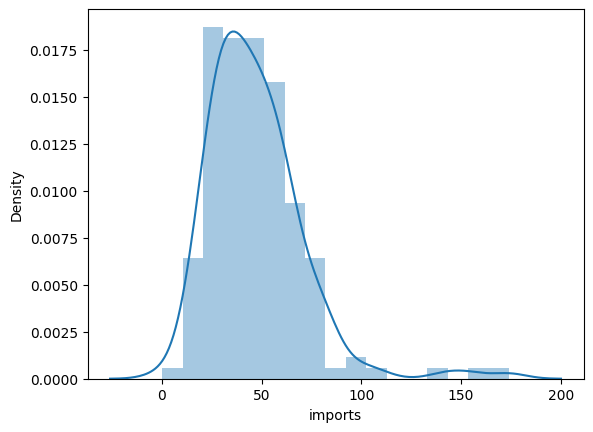

In [67]:
sns.distplot(df["imports"])

/tmp/ipython-input-658518250.py:1: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




<Axes: xlabel='income', ylabel='Density'>

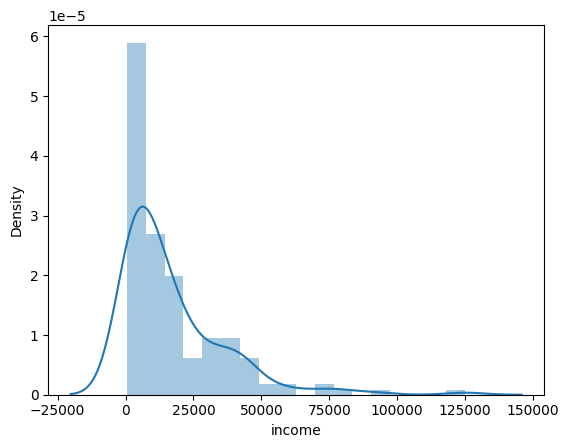

In [68]:
sns.distplot(df["income"])

/tmp/ipython-input-486343668.py:1: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




<Axes: xlabel='inflation', ylabel='Density'>

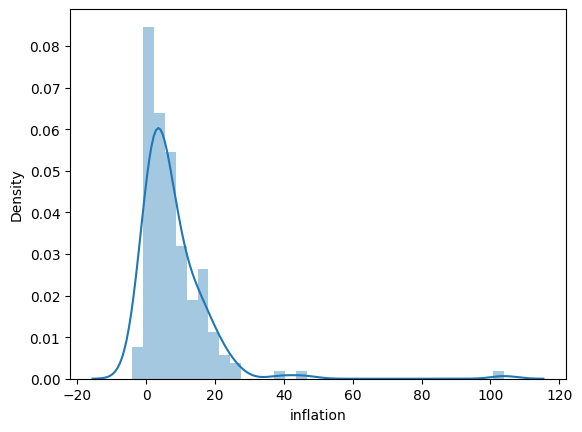

In [69]:
sns.distplot(df["inflation"])

/tmp/ipython-input-1046873682.py:1: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




<Axes: xlabel='life_expec', ylabel='Density'>

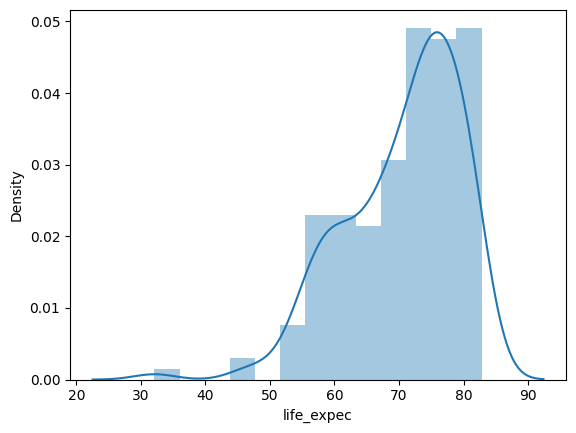

In [70]:
sns.distplot(df["life_expec"])

/tmp/ipython-input-803759703.py:1: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




<Axes: xlabel='total_fer', ylabel='Density'>

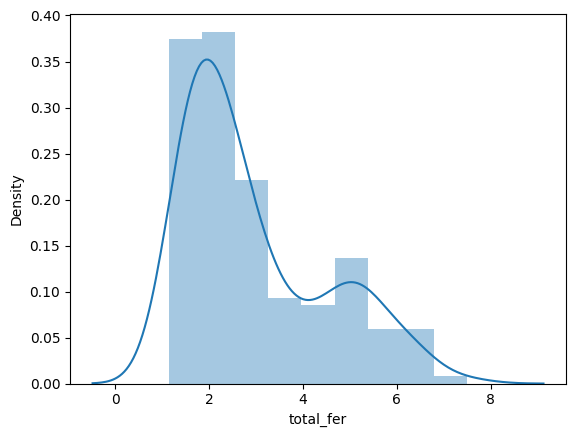

In [71]:
sns.distplot(df["total_fer"])

Tras analizar las distribuciones nos encontramos con ciertos outliers representan países con características socioeconómicas extremas pero legítimas, por eso no es necesario EN ESTE CASO realizar un tratamiento de los datos. Unos ejemplos ueden ser:

Income/GDPP alto: Luxemburgo, Qatar, Singapur (países genuinamente ricos)
Child_mort alto: Chad, Somalia, Angola (crisis humanitarias reales)
Life_expec bajo: Países con conflictos o sistemas de salud precarios
Inflation extrema: Venezuela, Zimbabue (crisis económicas reales)

Por último, para igualar las escalas estandarizaremos las variables. Para escalar las variables se va a usar RobustScaler, que es robusto a outliers al usar la mediana y el rango intercuartílico en lugar de la media y desviación estándar.

## 3 Extracción de las características

**Ejercicio 2** - Realizaremos transformaciones en nuestros datos en crudo para obtener las variables con las que realizar el clustering.

*   Muestra la matriz de correlaciones por pantalla y comenta resumidamente sus conclusiones.

*   Vamos a **agrupar todas nuestras nueve variables en tres grandes indicadores** diferentes: **Salud** (4 variables), **Comercio** (2 variables) y **Finanzas** (3 variables). Definir las agrupaciones en base a lo que significa cada variable. Para construir cada uno de los indicadores, sumaremos cada una de las variables agrupadas en ese indicador dividida por su media (Por ejemplo: Comercio = (variable1/media_variable1) + (variable2/media_variable2)

* Una vez construidos los indicadores, tenemos que asegurarnos que los tres estén a la **misma escala**. Para ello tenemos que decidirnos por la **estandarización** o la **normalización**, ambas funciones nativas de SKLearn. Visualiza la distribución de los 3 grandes indicadores, decide que método emplear (estandarización/normalización) y aplícalo a nuestros datos.






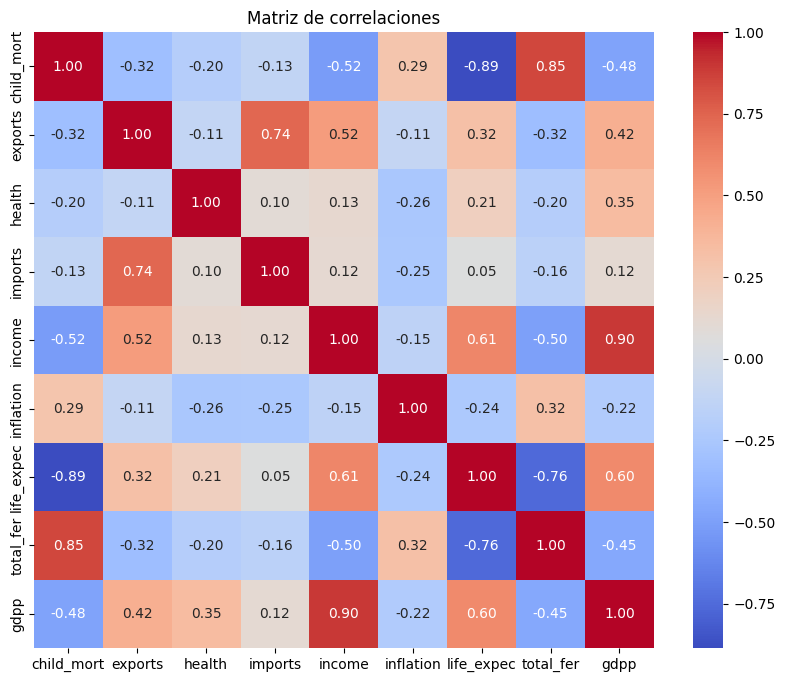

In [72]:
#matriz de correlaciones de las variables del dataset

plt.figure(figsize=(10, 8))

#seleccionar solo columnas numéricas (excluye 'country')
columnas_numericas = df.select_dtypes(include=np.number).columns

#calcular correlaciones solo de variables numéricas
sns.heatmap(df[columnas_numericas].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlaciones")
plt.show()

La matriz de correlaciones muestra relaciones claras entre algunas variables socioeconómicas.
Destacan correlaciones negativas entre el ingreso (income) y la mortalidad infantil (child_mort), así como correlaciones positivas entre ingreso y esperanza de vida (life_expec).
Estas relaciones justifican la creación de indicadores agregados que sinteticen la información y reduzcan la dimensionalidad del problema.

Teniendo en cuenta la matriz de correlaciones anterior, la agrupación de las variables quedaría de la siguiente manera:

Salud (4 variables):
child_mort
life_expec
total_fer
health
Comercio (2 variables):
exports
imports
Finanzas (3 variables):
income
inflation
gdpp






In [73]:
#CREACION DE LOS INDICADORES
# Indicador de Salud
df['salud'] = (
    (df['life_expec'] / df['life_expec'].mean()) +
    (df['health'] / df['health'].mean()) -
    (df['child_mort'] / df['child_mort'].mean()) -
    (df['total_fer'] / df['total_fer'].mean())
)

# Indicador de Comercio
df['comercio'] = (
    (df['exports'] / df['exports'].mean()) +
    (df['imports'] / df['imports'].mean())
)

# Indicador de Finanzas
df['finanzas'] = (
    (df['income'] / df['income'].mean()) +
    (df['gdpp'] / df['gdpp'].mean()) -
    (df['inflation'] / df['inflation'].mean())
)



Los indicadores se han construido combinando variables relacionadas conceptualmente.
Las variables que reflejan condiciones positivas para el desarrollo se suman, mientras que aquellas que representan factores negativos se restan, siguiendo un criterio interpretativo alineado con el contexto del problema.

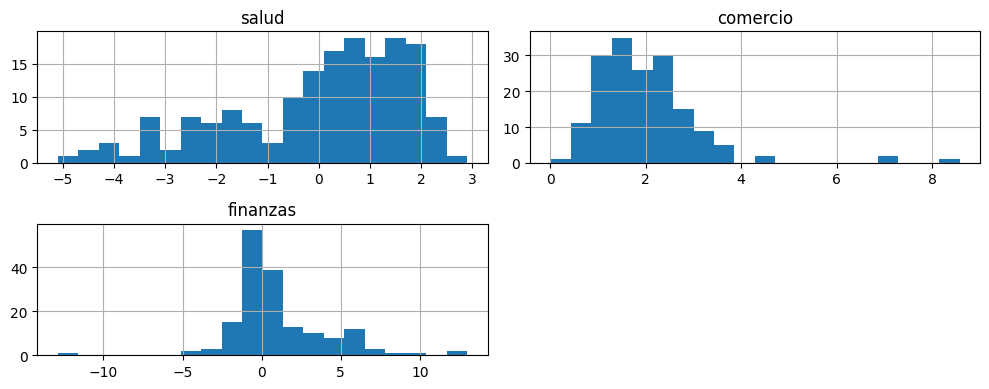

In [74]:
#visualizacion de los indicadores
df[['salud', 'comercio', 'finanzas']].hist(figsize=(10,4), bins=20)
plt.tight_layout()
plt.show()


Se observa que los indicadores presentan distribuciones no normales y la presencia de valores extremos, lo que sugiere la necesidad de escalar las variables antes de aplicar el algoritmo de clustering.

Se opta por la estandarización en lugar de la normalización debido a la presencia de outliers y a que las distribuciones no son normales. La estandarización permite que cada indicador tenga media cero y desviación típica uno, evitando que uno de ellos domine el proceso de agrupación.

In [75]:
scaler = StandardScaler()
indicadores_scaled = scaler.fit_transform(df[['salud', 'comercio', 'finanzas']])

df_scaled = pd.DataFrame(
    indicadores_scaled,
    columns=['salud_scaled', 'comercio_scaled', 'finanzas_scaled']
)


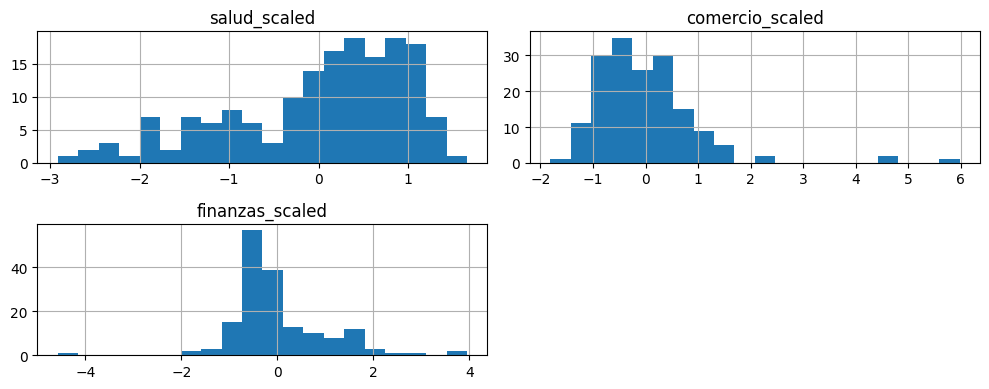

In [76]:
#visualización final tras escalar
df_scaled.hist(figsize=(10,4), bins=20)
plt.tight_layout()
plt.show()

## 4 Entrenamiento y evaluación del modelo

**Ejercicio 3**: Una vez tenemos los datos estandarizados, procedemos a aplicar nuestro método de agrupación.

*  **Selección del algoritmo de clustering**: Argumentar de manera razonada, teniendo en cuenta nuestro problema concreto, que método de agrupación es mejor aplicar en este caso. Existe uno claramente diferenciado.

* **Ajuste de hiperparámetro/s**: Una vez seleccionado el modelo, ajusta los hiperparámetro/s para decidir el o los mejores valores del mismo. Recuerda utilizar todas las técnicas vistas en clase y hacer un análisis completo de la situación para poder tomar la decisión con toda la información disponible. La elección de los valor/es de los hiperparámetros deben estar justificados con gran profundidad y evidencias.

* **Evaluación de la agrupación**: Utiliza métricas vistas en clase y la representación visual de la agrupación final realizada para valorar la calidad de la misma. Usa las librerías 2D y 3D vistas en las prácticas.





Para este problema se ha optado por el algoritmo K-means, ya que permite agrupar los países en clústeres bien definidos en función de indicadores interpretables.

Además, K-means es especialmente adecuado cuando se busca segmentar los datos en un número reducido de grupos, como es el caso de los distintos niveles de ayuda humanitaria.

Aunque el dataset presenta valores extremos, estos no se consideran errores, sino países con situaciones económicas muy diferenciadas (muy ricos o muy pobres), por lo que no se descartan y se preserva su influencia en el proceso de agrupación.

**Se utilizan los tres indicadores estandarizados como entrada al algoritmo de clustering para garantizar que todas las dimensiones contribuyan de manera equilibrada.**

Se eliminan las observaciones con valores faltantes únicamente para el entrenamiento del modelo, ya que K-means no admite valores NaN. Esta decisión no afecta a la interpretación global del análisis.

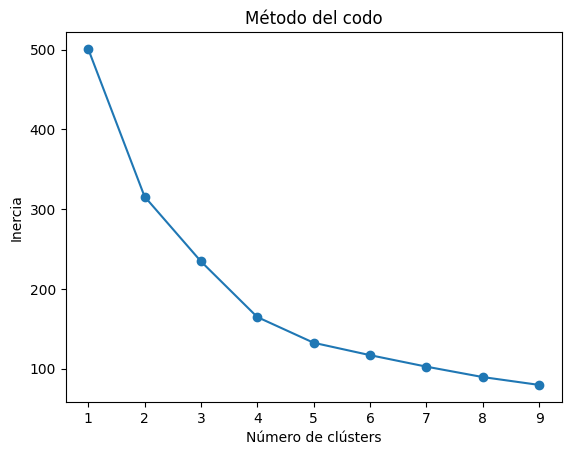

In [77]:
#unimos indicadores escalados con el dataframe original
df_model = pd.concat([df, df_scaled], axis=1)

#eliminamos filas con NaN en las variables usadas para el clustering
df_model = df_model.dropna(subset=['salud_scaled', 'comercio_scaled', 'finanzas_scaled'])

X = df_model[['salud_scaled', 'comercio_scaled', 'finanzas_scaled']]

inertia = []
K = range(1,10)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=50)
    km.fit(df_scaled)
    inertia.append(km.inertia_)


plt.plot(K, inertia, marker='o')
plt.xlabel('Número de clústers')
plt.ylabel('Inercia')
plt.title('Método del codo')
plt.show()

El método del codo sugiere que a partir de K=4 la reducción de la inercia deja de ser significativa, lo que indica que este valor ofrece un buen equilibrio entre complejidad y capacidad explicativa.

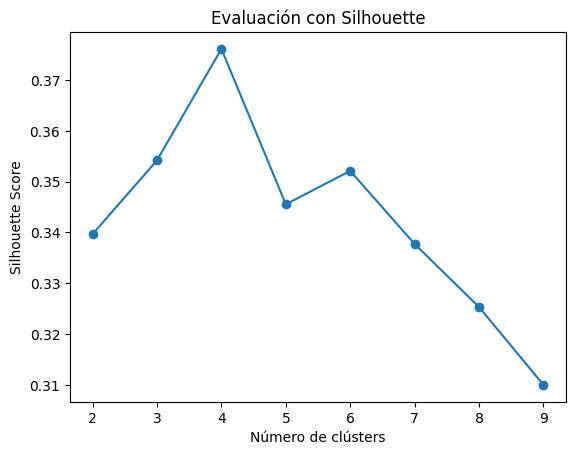

In [78]:
from sklearn.metrics import silhouette_score

sil_scores = []
# K should start from 2 for silhouette_score
for k in range(2, max(K)+1):
    km = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels = km.fit_predict(df_scaled)
    sil_scores.append(silhouette_score(df_scaled, labels))

# Adjust K for plotting silhouette scores to match the range used
plt.plot(range(2, max(K)+1), sil_scores, marker='o')
plt.xlabel('Número de clústers')
plt.ylabel('Silhouette Score')
plt.title('Evaluación con Silhouette')
plt.show()

El coeficiente de silueta alcanza valores elevados en torno a K=4, indicando una buena separación entre clústers y coherencia interna de los mismos.

Aunque otros valores de K también pueden resultar razonables dependiendo de la inicialización del algoritmo, se selecciona K=4 ya que es consistente con el método del codo, presenta un buen valor del coeficiente de silueta y permite una interpretación clara de los países en cuatro niveles diferenciados de necesidad de ayuda.

Se entrena el modelo final utilizando K=4 y se asigna a cada país la etiqueta de clúster correspondiente.

In [79]:
kmeans = KMeans(n_clusters=4, random_state=42)
df_model['cluster'] = kmeans.fit_predict(X)

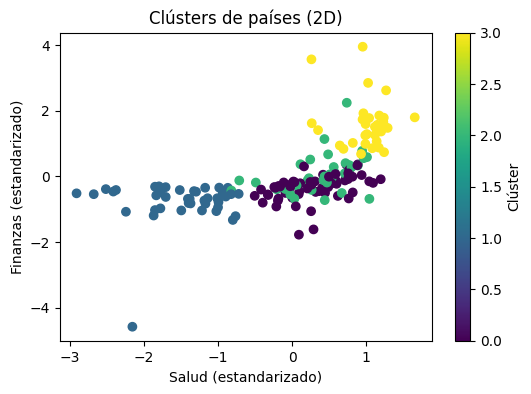

In [80]:
# VISUALIZACIÓN 2D DE LOS CLÚSTERES

kmeans = KMeans(n_clusters=4, random_state=42)
df_model['cluster'] = kmeans.fit_predict(X)

plt.figure(figsize=(6,4))
plt.scatter(
    df_model['salud_scaled'],
    df_model['finanzas_scaled'],
    c=df_model['cluster'],
    cmap='viridis'
)
plt.xlabel("Salud (estandarizado)")
plt.ylabel("Finanzas (estandarizado)")
plt.title("Clústers de países (2D)")
plt.colorbar(label="Clúster")
plt.show()

Se observa una separación clara entre los distintos grupos, especialmente entre los países con peores indicadores de salud y finanzas y aquellos con mejores condiciones socioeconómicas.

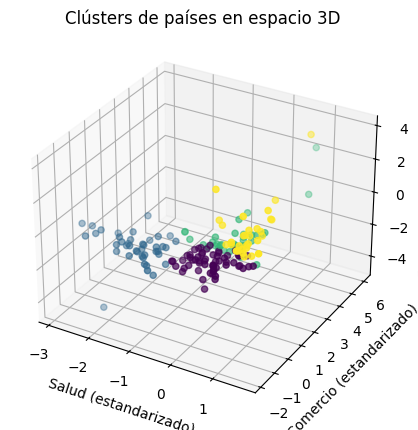

In [81]:
# VISUALIZACIÓN 3D DE LOS CLÚSTERES
fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df_model['salud_scaled'],
    df_model['comercio_scaled'],
    df_model['finanzas_scaled'],
    c=df_model['cluster'],
    cmap='viridis'
)

ax.set_xlabel('Salud (estandarizado)')
ax.set_ylabel('Comercio (estandarizado)')
ax.set_zlabel('Finanzas (estandarizado)')
ax.set_title('Clústers de países en espacio 3D')

plt.show()


La representación tridimensional permite apreciar de forma más clara la separación entre clústers, confirmando la calidad de la agrupación obtenida.

En conjunto, el modelo K-means con K=4 ofrece una segmentación coherente, estable e interpretable de los países en función de sus indicadores socioeconómicos.
Esta agrupación resulta especialmente adecuada para el objetivo del estudio, ya que facilita la identificación de distintos niveles de prioridad en la asignación de ayuda internacional.

## 5 Análisis de resultados y conclusión del problema.

**Ejercicio 4**: Interpretar y explicar los resultados obtenidos en base a nuestro problema concreto.

* Desde la ONG se tiene conocimiento de que las variables más representativas para decidir si un país necesita o no ayuda son el ingreso neto (income) y la mortalidad infantil (child_mort). Dibuja un boxplot de ambas variables respecto a los clústeres etiquetados para determinar el nivel de ayuda para cada uno de los diferentes grupos. **Nota**: Si hemos obtenido dos clústers finales, los niveles de ayuda serán (necesita ayuda/no necesita ayuda), si son 3 (no necesita ayuda / necesita ayuda moderada/ necesita mucha ayuda) y así sucesivamente.

*   Utilizando la librería *kaileido* y *plotly.express* **dibuja un mapa mundi** dónde se refleje el nivel de ayuda necesario por país en función de los clústeres realizados. Que cada nivel de ayuda (clúster) tenga un color diferente.


*   **Conclusiones**: En función de nuestro análisis, ¿qué países debería priorizar Ayuda Internacional para depositar su ayuda y sus recursos? ¿Qué mejoras o implementaciones podríamos hacer a este análisis para mejorar sus resultados? Razona las respuestas de manera argumentada.

Desde la ONG se considera que las variables más relevantes para determinar la necesidad de ayuda son el ingreso neto (income) y la mortalidad infantil (child_mort).
Por este motivo, se analizan ambas variables en función de los clústers obtenidos para poder asignar un nivel de ayuda a cada grupo de países.

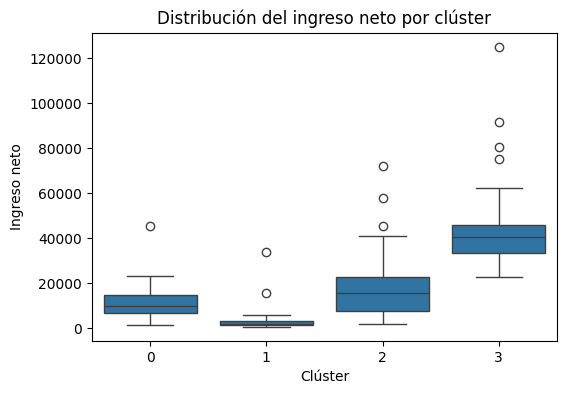

In [82]:
# Boxplot de income por clúster
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(x='cluster', y='income', data=df_model)
plt.title("Distribución del ingreso neto por clúster")
plt.xlabel("Clúster")
plt.ylabel("Ingreso neto")
plt.show()

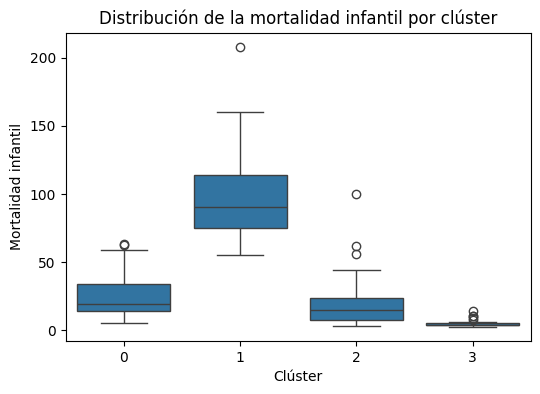

In [83]:
#Boxplot de child_mort por clúster
plt.figure(figsize=(6,4))
sns.boxplot(x='cluster', y='child_mort', data=df_model)
plt.title("Distribución de la mortalidad infantil por clúster")
plt.xlabel("Clúster")
plt.ylabel("Mortalidad infantil")
plt.show()

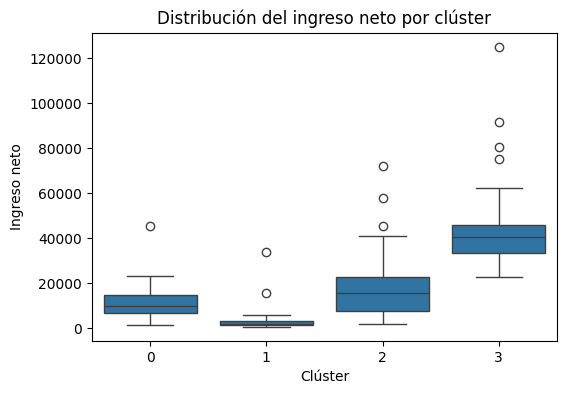

In [84]:
# Boxplot de income por clúster
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(x='cluster', y='income', data=df_model)
plt.title("Distribución del ingreso neto por clúster")
plt.xlabel("Clúster")
plt.ylabel("Ingreso neto")
plt.show()

A partir de los boxplots se observa que los clústers presentan diferencias claras en términos de ingreso y mortalidad infantil.

Los clústers con menores ingresos medios y mayores tasas de mortalidad infantil corresponden a los países que requieren un mayor nivel de ayuda.
Por el contrario, los clústers con ingresos elevados y baja mortalidad infantil representan países con menor necesidad de intervención por parte de la ONG.

Cabe destacar que el identificador numérico del clúster no implica un orden jerárquico, por lo que la asignación del nivel de ayuda se realiza en función de la interpretación de estas variables y no del valor de la etiqueta.

Suponiendo K = 4, podemos definir:

Nivel 0 → Nivel de necesidad extrema

Nivel 1 → Necesita mucha ayuda

Nivel 2 → Necesita ayuda moderada

Nivel 3 → No necesita ayuda

En función de los resultados observados, se asigna un nivel de ayuda a cada clúster considerando conjuntamente el ingreso neto y la mortalidad infantil. Esta categorización permite traducir los resultados del modelo de clustering en decisiones prácticas para la ONG.

Para facilitar la comprensión de los resultados y apoyar la toma de decisiones estratégicas, se representa el nivel de ayuda necesario para cada país en un mapa mundi.

In [86]:
# Asignar el "Nivel de ayuda" a cada clúster basándose en la interpretación previa
# Primero, aseguramos que la columna 'cluster' esté en df_model
# (Esto ya se hace en celdas anteriores, pero lo mantengo por robustez)
# kmeans = KMeans(n_clusters=4, random_state=42)

def map_cluster_to_aid_level(cluster_label):
    if cluster_label == 0:
        return "Nivel de necesidad extrema"
    elif cluster_label == 1:
        return "Necesita mucha ayuda"
    elif cluster_label == 2:
        return "Necesita ayuda moderada"
    elif cluster_label == 3:
        return "No necesita ayuda"
    else:
        return "Desconocido" # Manejo de clústeres no esperados

df_model['Nivel de ayuda'] = df_model['cluster'].apply(map_cluster_to_aid_level)

fig = px.choropleth(
    df_model,
    locations="country",
    locationmode="country names",
    color="Nivel de ayuda",
    title="Nivel de ayuda necesaria por país",
    color_continuous_scale="Viridis"
)

fig.show()

Cada color representa un clúster distinto, lo que permite identificar visualmente regiones del mundo con mayores necesidades de ayuda humanitaria.

A partir del análisis realizado, se concluye que los países pertenecientes a los clústers caracterizados por bajo ingreso neto y alta mortalidad infantil deberían ser priorizados para la asignación de recursos.

Estos países presentan condiciones socioeconómicas y sanitarias más desfavorables, lo que justifica una intervención urgente por parte de la ONG. Por el contrario, los países con mejores indicadores económicos y de salud requieren una menor prioridad en la distribución de la ayuda.

El uso de técnicas de clustering ha permitido segmentar los países de forma objetiva y basada en datos, facilitando una toma de decisiones más informada y transparente.